# FWI · frequency-selection source encoding (streamer, multiscale)

Conventional FWI pays one forward (and one backward) per shot. *Source
encoding* fires many shots in one simulation; the catch is crosstalk — the
misfit can no longer tell which shot produced which wiggle.

**Frequency selection** (Tromp & Bachmann, 2019) removes the crosstalk exactly:

1. Every shot radiates a **continuous monochromatic** source, each at its
   **own** frequency $f_s$.
2. All shots fire **together**, in one forward.
3. Once the wavefield is steady, take the DFT of a window of $n_p$ samples.
   If every $f_s = k_s / (n_p\,\Delta t)$ with integer $k_s$ (an exact DFT
   bin of the window), the bins are orthogonal and shot $s$ comes back out of
   bin $k_s$ with **zero** leakage from the others.
4. Compare with the observed data at the same $(s, f_s)$ through a
   **complex-cosine coherence** (GCN) per shot,
   $$J_s = 1 - \frac{|\langle u_s, d_s\rangle|}{\|u_s\|\,\|d_s\|},$$
   where the inner product runs over **shot $s$'s own traces**. $J_s$ does not
   change if $u_s$ or $d_s$ is multiplied by any complex number, so the source
   spectrum cancels: **the inversion needs no wavelet at all**.
5. Re-draw the shot → frequency assignment at random every iteration, so each
   shot sees the whole band over the run.

The survey is a **towed streamer**: 129 shots every 100 m, each with its own
4 km cable behind it. The inversion is **multiscale** — three comb bands,
1.5–3, 2.5–5 and 4–10 Hz — and every band runs on **its own grid and time
step**, sized to its highest frequency. The low band on a 100 m grid costs a
small fraction of what it would on the final 25 m grid.

The whole method is ~60 lines of torch on top of a plain `PropTorch` solver.
The production version (node pools, pre-extracted coefficient shards, domain
decomposition, OBN reciprocity) is `source_encoding.mode: frequency_selection`
in **sweep-tasks**.

## 1. Parameters

One row per band. The grid keeps $\geq 5$ points per wavelength at the band's
highest frequency in water ($v_{\min} = 1500$ m/s); the time step scales with
the grid so the Courant number stays the same. Every length in the survey
(shot spacing, group interval, tow depth) is a multiple of 100 m, so the
geometry sits exactly on grid points at 100, 50 and 25 m.

In [1]:
import time
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from sweep.equations import Acoustic
from sweep.propagator.torch import PropTorch
from sweep.signal import ricker
from sweep.datasets import load_marmousi, MARMOUSI_DH

bands = [   # comb band (Hz), grid (m), time step (s), iterations, Adam lr (m/s)
    {'f_lo': 1.5, 'f_hi':  3.0, 'dh': 100.0, 'dt': 0.008, 'n_iter': 100, 'lr': 20.0},
    {'f_lo': 2.5, 'f_hi':  5.0, 'dh':  50.0, 'dt': 0.004, 'n_iter': 100, 'lr': 12.0},
    {'f_lo': 4.0, 'f_hi': 10.0, 'dh':  25.0, 'dt': 0.002, 'n_iter': 100, 'lr':  6.0},
]

# Survey, in metres: streamer towed to the left of the gun.
shot_x = np.arange(4100.0, 16901.0, 100.0)    # 129 shots, 100 m apart
offsets = np.arange(100.0, 4001.0, 100.0)     # 40 groups, 100 m .. 4 km
tow_z = 100.0                                 # source and cable depth
nshots = len(shot_x)

# Observed data: a conventional transient survey, Ricker 5 Hz, 10 s records.
# The wavelet is used HERE ONLY — the inversion never sees it.
f_ricker, delay, t_obs = 5.0, 0.3, 10.0

# Every shot needs its own comb bin and the bin spacing is 1 / (n_p * dt), so a
# band of width B holding nb bins needs a window n_p * dt = nb / B:
# more shots buy a LONGER WINDOW, not more forwards.
nb = nshots + 1                     # one spare bin per band
t_ring, t_slack = 7.0, 0.5          # ring-up before the window; two-window offset
pml_m, spatial_order = 1500.0, 8

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
equation = Acoustic(device=device, spatial_order=spatial_order)
vp_true_12 = load_marmousi('true')          # native 12.5 m grid
vp_init_12 = load_marmousi('smooth')
print('device:', device, ' Marmousi', vp_true_12.shape, f'@ {MARMOUSI_DH} m')

device: cuda  Marmousi (281, 1361) @ 12.5 m


## 2. Per-band grid, geometry, comb and observed data

`setup_band` builds everything a band needs on its own grid:

* the true and starting models, decimated exactly from the 12.5 m original;
* shot and receiver indices, and the union receiver table (every cable
  position) with a `mask[s, r]` that keeps each shot to its own 40 traces;
* the comb: `n_p`, the integer bins `ks`, the frequencies `f`;
* the observed coefficients `D[s, k, r]`: a conventional transient forward
  per shot on the band's grid, then a DTFT of every trace at every comb
  frequency, scattered onto the union table.

The observed data are synthesised **per band on that band's grid**, so the
coarse bands never fit the numerical-dispersion difference between two grids.
On field data there is one recorded survey, and this step is a DTFT of it per
band.

In [2]:
def on_grid(a, dh):
    s = int(round(dh / MARMOUSI_DH))
    assert (a.shape[0] - 1) % s == 0 and (a.shape[1] - 1) % s == 0
    return a[::s, ::s].copy()


def idx(x_m, dh):
    i = np.round(np.asarray(x_m) / dh).astype(np.int64)
    assert np.allclose(i * dh, x_m), 'geometry must sit on grid points'
    return i


def setup_band(b):
    dh, dt = b['dh'], b['dt']
    b['vp_true'] = on_grid(vp_true_12, dh)
    b['nz'], b['nx'] = nz, nx = b['vp_true'].shape
    b['water_rows'] = int(np.argmax((b['vp_true'] > 1500.5).any(axis=1)))
    b['abcn'] = int(round(pml_m / dh))
    b['courant'] = vp_true_12.max() * dt / dh

    zs = idx(tow_z, dh)
    b['src'] = np.stack([idx(shot_x, dh), np.full(nshots, zs)], axis=1)
    rec_x = np.arange(0, nx, idx(100.0, dh))                       # union table
    b['rec'] = np.stack([rec_x, np.full(len(rec_x), zs)], axis=1)
    trace_x = idx(shot_x[:, None] - offsets[None], dh)              # (nshots, ntr)
    cols = np.searchsorted(rec_x, trace_x)
    assert np.all(rec_x[cols] == trace_x)
    b['mask'] = torch.zeros(nshots, len(rec_x), device=device)
    b['mask'][np.arange(nshots)[:, None], cols] = 1.0

    b['n_p'] = int(round(nb / (b['f_hi'] - b['f_lo']) / dt))
    b['ks'] = int(round(b['f_lo'] * b['n_p'] * dt)) + np.arange(nb)
    b['f'] = b['ks'] / (b['n_p'] * dt)
    b['n_ss'], b['slack'] = int(round(t_ring / dt)), int(round(t_slack / dt))
    b['nt'] = b['n_ss'] + b['slack'] + b['n_p']

    # observed: transient shot gathers on this grid -> DTFT at the comb
    nt_obs = int(round(t_obs / dt))
    t = np.arange(nt_obs, dtype=np.float32) * dt
    wavelet = ricker(t - delay, f=f_ricker).astype(np.float32)
    obs_solver = PropTorch(equation, shape=(nz, nx), dh=dh, dt=dt, nt=nt_obs,
                           abcn=b['abcn'], impl='c')
    streamers = np.stack([trace_x, np.full_like(trace_x, zs)], axis=-1)
    vt = torch.tensor(b['vp_true'], device=device)
    with torch.no_grad():
        d = torch.cat([obs_solver(wavelet, b['src'][i:i + 16], streamers[i:i + 16],
                                  models=[vt])[..., 0]
                       for i in range(0, nshots, 16)])             # (nshots, nt, ntr)
    tt = torch.arange(nt_obs, device=device, dtype=torch.float64) * dt
    E = torch.exp(-2j * np.pi * torch.tensor(b['f'], device=device)[:, None]
                  * tt[None]).to(torch.complex64)
    Ds = torch.einsum('str,kt->skr', d.to(torch.complex64), E)
    ix = torch.tensor(cols, device=device)[:, None, :].expand(-1, nb, -1)
    b['D'] = torch.zeros(nshots, nb, len(rec_x), dtype=torch.complex64,
                         device=device).scatter_(2, ix, Ds)
    b['nt_obs'] = nt_obs


t0 = time.time()
for i, b in enumerate(bands):
    setup_band(b)
    print(f"band {i}: {b['f'][0]:.2f}-{b['f'][-1]:.2f} Hz | grid {b['nz']}x{b['nx']} "
          f"@ {b['dh']:.0f} m, dt {b['dt']*1e3:.0f} ms, Courant {b['courant']:.2f}, "
          f"ppw {1500/(b['f_hi']*b['dh']):.1f} | window {b['n_p']*b['dt']:.1f} s, "
          f"{b['nt']} steps / forward")
print(f'{nshots} shots x {len(offsets)} traces; setup {time.time()-t0:.0f} s')

band 0: 1.50-2.99 Hz | grid 36x171 @ 100 m, dt 8 ms, Courant 0.38, ppw 5.0 | window 86.7 s, 11770 steps / forward


band 1: 2.50-4.98 Hz | grid 71x341 @ 50 m, dt 4 ms, Courant 0.38, ppw 6.0 | window 52.0 s, 14875 steps / forward


band 2: 4.02-9.97 Hz | grid 141x681 @ 25 m, dt 2 ms, Courant 0.38, ppw 6.0 | window 21.7 s, 14583 steps / forward
129 shots x 40 traces; setup 5 s


## 3. The pieces of the method

* `encoded_wavelet` — row $s$ is $\mathrm{ramp}(t)\cos(2\pi f_{b_s} t)$; the
  raised-cosine ramp avoids radiating a step at $t=0$.
* `window_dft` — projects the steady window $[\,\text{start},\ \text{start}+n_p)$
  onto the fired frequencies: one `(nshots, n_p) @ (n_p, nrec)` product per
  real/imaginary part.
* `gcn_loss` — the per-shot coherence $J_s$ over shot $s$'s own traces
  (the `mask`), summed over shots.

All plain differentiable torch, so `loss.backward()` goes straight through the
solver.

In [3]:
def encoded_wavelet(b, bins, nt, ramp_s=0.5):
    tt = np.arange(nt) * b['dt']
    ramp = np.where(tt < ramp_s, 0.5 * (1 - np.cos(np.pi * tt / ramp_s)), 1.0)
    w = ramp * np.cos(2 * np.pi * b['f'][bins][:, None] * tt)
    return torch.tensor(w, dtype=torch.float32, device=device)   # (nshots, nt)


def window_dft(y, b, bins, start):
    # y: (nt, nrec) record of the super-shot -> (nshots, nrec) real, imag
    tt = (start + torch.arange(b['n_p'], device=device, dtype=torch.float64)) * b['dt']
    f = torch.tensor(b['f'][bins], device=device)
    E = torch.exp(-2j * np.pi * f[:, None] * tt[None])
    ywin = y[start:start + b['n_p']]
    return E.real.float() @ ywin, E.imag.float() @ ywin


def gcn_loss(ur, ui, D, mask):
    # ur, ui: (nshots, nrec) synthetic; D: (nshots, nrec) complex observed
    ur, ui = ur * mask, ui * mask                  # each shot: its own cable only
    dr, di = D.real, D.imag
    re = (ur * dr + ui * di).sum(1)
    im = (ui * dr - ur * di).sum(1)
    num = torch.sqrt(re ** 2 + im ** 2)
    den = torch.sqrt((ur ** 2 + ui ** 2).sum(1)) * torch.sqrt((dr ** 2 + di ** 2).sum(1))
    return (1 - num / den).sum()


def make_solver(b, nt=None):
    return PropTorch(equation, shape=(b['nz'], b['nx']), dh=b['dh'], dt=b['dt'],
                     nt=nt or b['nt'], abcn=b['abcn'], impl='c')


def encoded_forward(solver, b, bins, vp):
    # ALL shots in ONE forward: sources (1, nshots, 2), receivers (1, nrec, 2)
    y = solver(encoded_wavelet(b, bins, solver.nt), b['src'][None], b['rec'][None],
               models=[vp])
    return y[0, :, :, 0]                                       # (nt, nrec)

## 4. Is the window steady? Is the separation exact?

Two checks on the **true** model, before any inversion:

* **two-window check** — extract the coefficients from two windows 0.5 s
  apart; once the field is steady they agree. Each shot only has to be steady
  **on its own cable**, so the ring-up is set by the 4 km maximum offset, not
  by the 17 km model.
* **$J$(true)** — the GCN misfit between the encoded super-shot and the
  transient observed data. If the separation is exact and the wavelet really
  cancels, it is (close to) zero.

First on the coarse band, for three ring-up lengths — too short a ring-up
shows up in **both** numbers:

In [4]:
rows = np.arange(nshots)


def steady_check(b, n_ss, seed=0):
    bins = np.random.default_rng(seed).permutation(nb)[:nshots]
    s = make_solver(b, nt=n_ss + b['slack'] + b['n_p'])
    with torch.no_grad():
        y = encoded_forward(s, b, bins, torch.tensor(b['vp_true'], device=device))
    A = torch.complex(*window_dft(y, b, bins, n_ss)) * b['mask']
    C = torch.complex(*window_dft(y, b, bins, n_ss + b['slack'])) * b['mask']
    rel = ((A - C).abs().norm(dim=1) / C.abs().norm(dim=1)).median().item()
    J0 = gcn_loss(C.real, C.imag, b['D'][rows, bins], b['mask']).item() / nshots
    return rel, J0, y, bins


b = bands[0]
for t_try in [3.0, 5.0, t_ring]:
    rel, J0, _, _ = steady_check(b, int(round(t_try / b['dt'])))
    print(f'band 0, ring-up {t_try:4.1f} s: two-window {rel:.1e}   J(true) per shot {J0:.1e}')

band 0, ring-up  3.0 s: two-window 1.1e-02   J(true) per shot 1.4e-04


band 0, ring-up  5.0 s: two-window 3.4e-03   J(true) per shot 5.4e-05
band 0, ring-up  7.0 s: two-window 1.0e-03   J(true) per shot 4.5e-05


Then every band at the chosen 7 s ring-up:

In [5]:
for i, b in enumerate(bands):
    rel, J0, y, bins = steady_check(b, b['n_ss'])
    print(f'band {i}: two-window {rel:.1e}   J(true) per shot {J0:.1e}')
y_demo, bins_demo = y.cpu().numpy(), bins

band 0: two-window 1.0e-03   J(true) per shot 4.5e-05


band 1: two-window 8.7e-04   J(true) per shot 5.9e-06


band 2: two-window 3.3e-03   J(true) per shot 2.3e-05


What the super-shot looks like on the finest band: the encoded record (all
129 shots at once) and the spectrum of its steady window at one receiver.
Every window bin is shown: energy sits on the fired comb bins, and the one
**spare** bin — fired by nobody this time — is orders of magnitude down.
That is the zero-crosstalk property, measured.

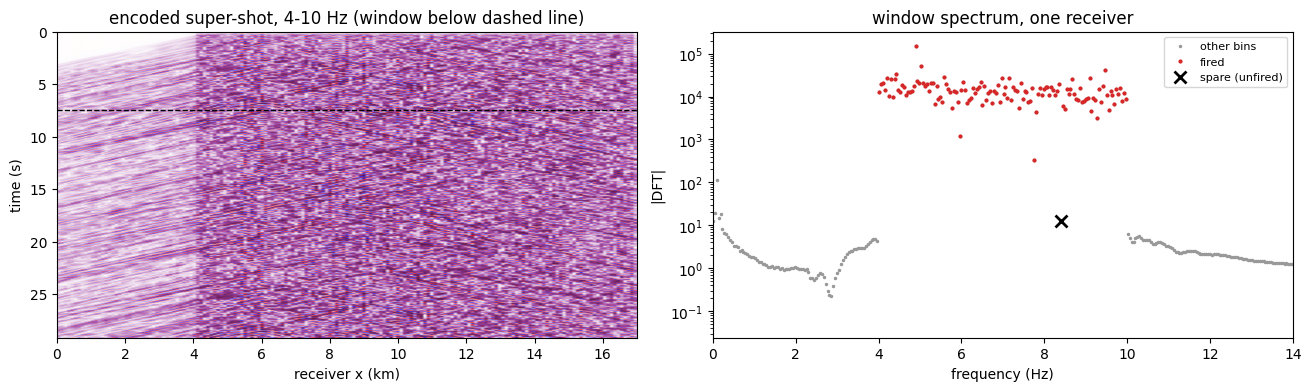

In [6]:
b = bands[-1]
start = b['n_ss'] + b['slack']
ir = b['rec'].shape[0] // 2
spec = np.abs(np.fft.rfft(y_demo[start:start + b['n_p'], ir]))
fax = np.fft.rfftfreq(b['n_p'], b['dt'])
spare = np.setdiff1d(np.arange(nb), bins_demo)

fig, ax = plt.subplots(1, 2, figsize=(13, 3.8), constrained_layout=True)
v = np.percentile(np.abs(y_demo), 99)
ax[0].imshow(y_demo, cmap='seismic', vmin=-v, vmax=v, aspect='auto',
             extent=[0, (b['nx'] - 1) * b['dh'] / 1000, y_demo.shape[0] * b['dt'], 0])
ax[0].axhline(start * b['dt'], color='k', ls='--', lw=1)
ax[0].set_xlabel('receiver x (km)'); ax[0].set_ylabel('time (s)')
ax[0].set_title('encoded super-shot, 4-10 Hz (window below dashed line)')
ax[1].plot(fax, spec, '.', color='0.6', ms=3, label='other bins')
ax[1].plot(b['f'][bins_demo], spec[b['ks'][bins_demo]], '.', color='tab:red', ms=4,
           label='fired')
ax[1].plot(b['f'][spare], spec[b['ks'][spare]], 'x', color='k', ms=8, mew=2,
           label='spare (unfired)')
ax[1].set_xlim(0, 14); ax[1].set_yscale('log'); ax[1].legend(fontsize=8)
ax[1].set_xlabel('frequency (Hz)'); ax[1].set_ylabel('|DFT|')
ax[1].set_title('window spectrum, one receiver')
plt.show()

## 5. Multiscale FWI loop

Per band: bring the model onto the band's grid (bilinear; the grids share
their corner nodes), put the known water back, then iterate — a fresh
shot → bin permutation, **one** encoded forward with all 129 shots, window
DFT, GCN, backward. The water layer's gradient is zeroed.

In [7]:
def regrid(v, shape):
    return F.interpolate(v[None, None], size=shape, mode='bilinear',
                         align_corners=True)[0, 0]


rng = np.random.default_rng(0)
vp_np = on_grid(vp_init_12, bands[0]['dh'])
history, snapshots = [], [(bands[0]['dh'], vp_np.copy())]
for bi, b in enumerate(bands):
    init_b = on_grid(vp_init_12, b['dh'])
    v = regrid(torch.tensor(vp_np, device=device), (b['nz'], b['nx']))
    v[:b['water_rows']] = torch.tensor(init_b[:b['water_rows']], device=device)
    vp = v.clone().requires_grad_(True)
    grad_mask = torch.ones_like(vp)
    grad_mask[:b['water_rows']] = 0

    solver = make_solver(b)
    opt = torch.optim.Adam([vp], lr=b['lr'])
    start = b['n_ss'] + b['slack']
    t0 = time.time()
    for it in range(b['n_iter']):
        bins = rng.permutation(nb)[:nshots]
        opt.zero_grad()
        y = encoded_forward(solver, b, bins, vp)
        loss = gcn_loss(*window_dft(y, b, bins, start), b['D'][rows, bins], b['mask'])
        loss.backward()
        vp.grad *= grad_mask
        opt.step()
        history.append((bi, loss.item() / nshots))
    vp_np = vp.detach().cpu().numpy()
    snapshots.append((b['dh'], vp_np.copy()))
    print(f"band {bi} ({b['f'][0]:.1f}-{b['f'][-1]:.1f} Hz @ {b['dh']:.0f} m): "
          f"{b['n_iter']} iters, {time.time()-t0:.0f} s")

band 0 (1.5-3.0 Hz @ 100 m): 100 iters, 40 s


band 1 (2.5-5.0 Hz @ 50 m): 100 iters, 50 s


band 2 (4.0-10.0 Hz @ 25 m): 100 iters, 55 s


## 6. Results

Each snapshot on its own grid; RMSE is measured below the water after
interpolating onto the 25 m grid. The first shot is at 4.1 km and its cable
reaches back to 0.1 km, so the left ~2 km is only seen at shallow depth — that
strip stays close to the starting model and weighs on the whole-section RMSE.

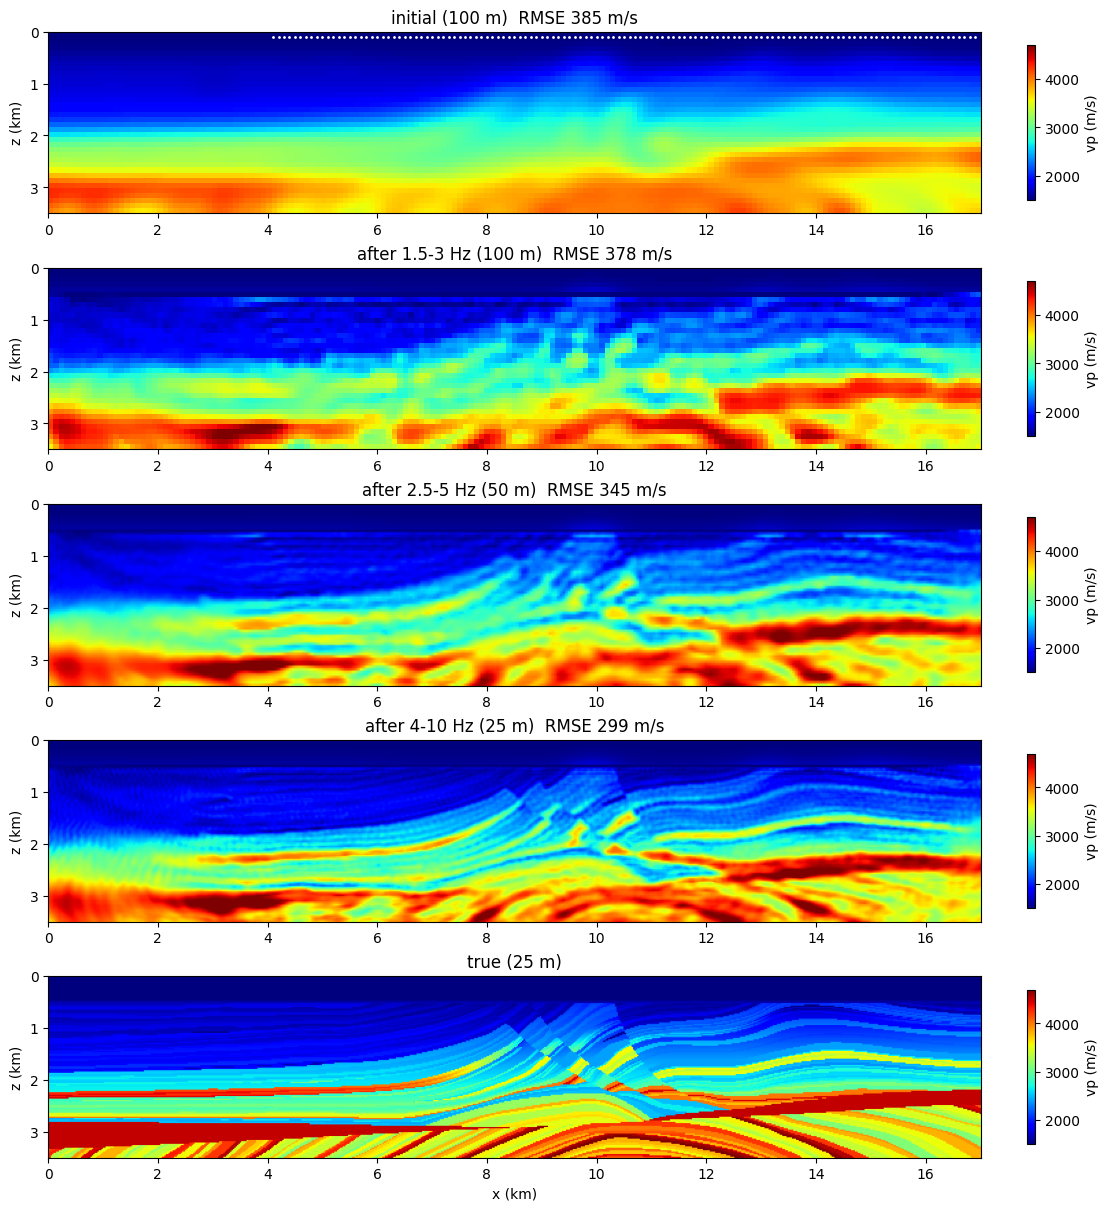

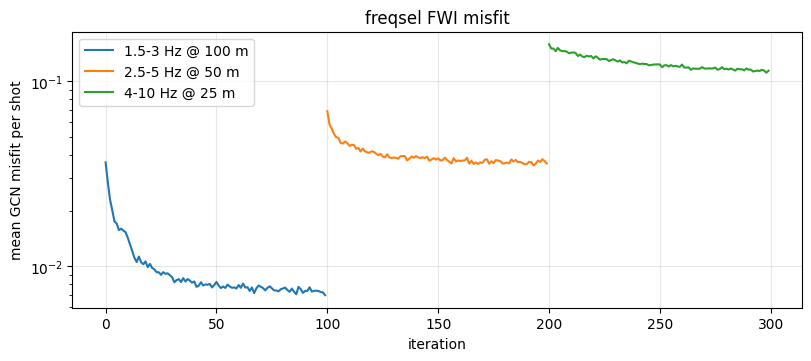

In [8]:
fine = bands[-1]
true_f = fine['vp_true']
labels = ['initial (100 m)', 'after 1.5-3 Hz (100 m)', 'after 2.5-5 Hz (50 m)',
          'after 4-10 Hz (25 m)', 'true (25 m)']
panels = [*snapshots, (fine['dh'], true_f)]
ext = [0, (fine['nx'] - 1) * fine['dh'] / 1000, (fine['nz'] - 1) * fine['dh'] / 1000, 0]
fig, axes = plt.subplots(len(panels), 1, figsize=(11, 12), constrained_layout=True)
for k, (ax, label, (dh, p)) in enumerate(zip(axes, labels, panels)):
    im = ax.imshow(p, cmap='jet', vmin=1500, vmax=4700, aspect='auto', extent=ext)
    if k < len(panels) - 1:
        pf = regrid(torch.tensor(p), true_f.shape).numpy()
        rmse = np.sqrt(((pf - true_f)[fine['water_rows']:] ** 2).mean())
        label = f'{label}  RMSE {rmse:.0f} m/s'
    ax.set_title(label); ax.set_ylabel('z (km)')
    fig.colorbar(im, ax=ax, label='vp (m/s)', shrink=0.85)
axes[0].plot(shot_x / 1000, np.full(nshots, tow_z / 1000), 'w.', ms=2)
axes[-1].set_xlabel('x (km)')
plt.show()

fig, ax = plt.subplots(figsize=(8, 3.5), constrained_layout=True)
h = np.array(history)
for bi, b in enumerate(bands):
    sel = np.where(h[:, 0] == bi)[0]
    ax.plot(sel, h[sel, 1], label=f"{b['f_lo']:g}-{b['f_hi']:g} Hz @ {b['dh']:.0f} m")
ax.set_xlabel('iteration'); ax.set_ylabel('mean GCN misfit per shot')
ax.set_yscale('log'); ax.grid(alpha=0.3); ax.legend()
ax.set_title('freqsel FWI misfit')
plt.show()

## 7. What it costs

The comparison that matters: the encoded iteration against a **conventional**
iteration that also uses **all 129 shots** for its gradient (transient Ricker,
10 s records, each shot on its own cable), on the **same** grid.

**In theory**, the cost per step is the same on both sides, so the speedup is
the ratio of time steps:

$$\text{speedup} = \frac{N\,T_{\text{rec}}}{T_{\text{ring}} + T_{\text{slack}} + (N+1)/B}$$

with $N$ shots, record length $T_{\text{rec}}$, band width $B$. As $N\to\infty$
it saturates at $T_{\text{rec}}\,B$: more shots need a proportionally longer
window, so a narrow band can never be sped up much.

In [9]:
for i, b in enumerate(bands):
    conv, enc = nshots * b['nt_obs'], b['nt']
    print(f"band {i} ({b['f_lo']:g}-{b['f_hi']:g} Hz @ {b['dh']:3.0f} m): "
          f"conventional {nshots} x {b['nt_obs']} = {conv:6d} steps   encoded {enc:5d}   "
          f"theory {conv/enc:4.1f}x   (limit {t_obs*(b['f_hi']-b['f_lo']):4.0f}x)")

band 0 (1.5-3 Hz @ 100 m): conventional 129 x 1250 = 161250 steps   encoded 11770   theory 13.7x   (limit   15x)
band 1 (2.5-5 Hz @  50 m): conventional 129 x 2500 = 322500 steps   encoded 14875   theory 21.7x   (limit   25x)
band 2 (4-10 Hz @  25 m): conventional 129 x 5000 = 645000 steps   encoded 14583   theory 44.2x   (limit   60x)


**Measured** on an idle RTX 6000 Ada (forward + backward per iteration,
median of 7), with the conventional side at its **fastest** batch size — it
stacks several shots on the batch dimension of one solver call:

| band | grid | theory | conventional, fastest (shots per call) | encoded | **measured** |
|---|---|---|---|---|---|
| 1.5–3 Hz | 100 m | 13.7× | 0.180 s (65) | 0.352 s | **0.5×** |
| 2.5–5 Hz | 50 m | 21.7× | 1.345 s (16) | 0.458 s | **2.9×** |
| 4–10 Hz | 25 m | 44.2× | 10.0 s (4) | 0.553 s | **18.1×** |

With one shot per call the conventional side measures 20×, 23× and 40× slower
than encoded — the theory, because then both sides push one wavefield at a
time.

**Why the measured speedup falls short.** The theory counts steps and assumes
a step costs the same on both sides. It does not: the encoded run is always
**one** wavefield, while the conventional run spreads the cost of a step over
the shots stacked in the batch. The measured speedup is the theory divided by

| grid | encoded, per step | conventional at its fastest, per shot per step | ratio |
|---|---|---|---|
| 100 m | 30 µs | 1.1 µs | 27 |
| 50 m | 31 µs | 4.2 µs | 7.4 |
| 25 m | 36 µs | 15.5 µs | 2.3 |

The smaller the grid, the less of the GPU one wavefield can use, and the larger
that ratio. Even at 25 m (~190 000 cells with the absorbing layer) a single
wavefield gets less than half of this card's throughput, so the encoded run
keeps ~40 % of the theoretical speedup. On a production-size model (a larger
2-D section, or 3-D) one wavefield fills the card by itself, the ratio goes to
1, and the measurement approaches the theory. At the size of this notebook,
only the 25 m band is really faster encoded; the coarse bands gain from their
coarse grids, not from the encoding. Splitting the shots into a few
independent super-shots on the batch dimension (each with its own, shorter
comb) would let the coarse bands fill the card too.

* **More shots need a longer window**, not more forwards:
  `bins = band width × window length`, and every shot needs its own bin.
* **The ring-up is the fixed cost**, set by the longest offset a shot has to
  be steady on — here the 4 km cable — in seconds, on every grid.
* **One frequency per shot per iteration.** The speedup above is per
  iteration; a conventional iteration uses each shot's whole spectrum, an
  encoded one a single frequency per shot, so iterations to the same model
  quality are not compared here. With 129 shots the fired frequencies cover
  the band densely in every iteration, and the random re-assignment covers
  each shot's spectrum over the run.
* **No wavelet anywhere** in the inversion — on field data, where the source
  signature, delay and receiver coupling are unknown, that is the point.

## Reference

Tromp, J., & Bachmann, E. (2019). Source encoding for adjoint tomography. *Geophysical Journal International, 218*(3), 2019–2044. [doi:10.1093/gji/ggz271](https://doi.org/10.1093/gji/ggz271) — the frequency-selection (steady-state comb) encoding implemented here.

---

<p><strong>Download this notebook</strong> &mdash; <a href="31_fwi_frequency_selection.ipynb" download><code>31_fwi_frequency_selection.ipynb</code></a> &middot; or <a href="https://github.com/DeepWave-KAUST/sweep/blob/dev/examples/notebooks/31_fwi_frequency_selection.ipynb">view on GitHub</a></p>